In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. LOAD DATA
# ==============================
df = pd.read_csv('/content/drive/MyDrive/capstone/dataset_tkpi.csv', sep=';')
df.head()

,No.,Kode Baru,Nama Bahan Makanan,Air,Energi,Protein,Lemak,Karbohidrat,Serat,Abu,...,karoten,Karoten total,Thiamin (vit. B1),Riboflavin (vit. B2),Niasin,Vitamin C,BDD,Mentah / Olahan,Kelompok Makanan,Sumber TKPI 2019
0,NaN,NaN,NaN,(g),(Kal),(g),(g),(g),(g),(g),...,(mcg),(mcg),(mg),(mg),(mg),(mg),(%),NaN,NaN,NaN
1,1,AP001,Nasi,567,180,30,3,398,2,2,...,-,-,5,10,26,-,100,Olahan,Serealia,KZGPI-1990
2,2,AP002,Nasi tim,710,120,24,4,260,5,2,...,-,-,10,-,14,-,100,Olahan,Serealia,OKN-1992
3,3,AP003,Tapai beras,755,99,17,3,224,-,1,...,-,-,-,-,-,-,100,Olahan,Serealia,KZGMI-2001
4,4,AP004,"Tepung beras, mentah",120,353,70,5,800,24,5,...,-,-,12,10,12,-,100,Olahan,Serealia,DABM-1964


In [ ]:
# 3. CEK KOLOM
# ==============================
print("Kolom awal:")
print(df.columns.tolist())


Kolom awal:
['No.', 'Kode Baru ', 'Nama Bahan Makanan ', 'Air ', 'Energi ', 'Protein ', 'Lemak ', 'Karbohidrat ', 'Serat ', 'Abu ', 'Kalsium  (Ca) ', 'Fosfor  (P) ', 'Besi  (Fe) ', 'Natrium  (Na) ', 'Kalium  (Ka) ', 'Tembaga  (Cu) ', 'Seng  (Zn) ', 'Retinol (vit. A) ', 'karoten ', 'Karoten total ', 'Thiamin (vit. B1) ', 'Riboflavin (vit. B2)', 'Niasin ', 'Vitamin C ', 'BDD ', 'Mentah / Olahan ', 'Kelompok Makanan', 'Sumber TKPI 2019 ']


In [ ]:
# 4. BERSIHKAN NAMA KOLOM
# ==============================
df.columns = df.columns.str.strip().str.lower()

print("\nKolom setelah cleaning:")
print(df.columns.tolist())



Kolom setelah cleaning:
['no.', 'kode baru', 'nama bahan makanan', 'air', 'energi', 'protein', 'lemak', 'karbohidrat', 'serat', 'abu', 'kalsium  (ca)', 'fosfor  (p)', 'besi  (fe)', 'natrium  (na)', 'kalium  (ka)', 'tembaga  (cu)', 'seng  (zn)', 'retinol (vit. a)', 'karoten', 'karoten total', 'thiamin (vit. b1)', 'riboflavin (vit. b2)', 'niasin', 'vitamin c', 'bdd', 'mentah / olahan', 'kelompok makanan', 'sumber tkpi 2019']


In [ ]:
# 5. RENAME KOLOM
# ==============================
df.rename(columns={
    'nama bahan makanan': 'makanan',
    'energi (kkal)': 'kalori',
    'protein (g)': 'protein',
    'lemak (g)': 'lemak',
    'karbohidrat (g)': 'karbohidrat',
    'natrium (mg)': 'natrium',
    'kalium (mg)': 'kalium',
    'fosfor (mg)': 'fosfor'
}, inplace=True)

In [ ]:
# 6. CEK MISSING VALUE
# ==============================
print("\nMissing values:")
print(df.isnull().sum())

missing_pct = df.isnull().sum() / len(df) * 100

# drop kolom dengan missing > 30%
drop_col = missing_pct[missing_pct > 30].index
df.drop(columns=drop_col, inplace=True)

# imputasi median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# drop baris tanpa nama makanan
if 'makanan' in df.columns:
    df.dropna(subset=['makanan'], inplace=True)


Missing values:
no.                     1
kode baru               1
makanan                 1
air                     0
energi                  0
protein                 0
lemak                   0
karbohidrat             0
serat                   0
abu                     0
kalsium  (ca)           0
fosfor  (p)             0
besi  (fe)              0
natrium  (na)           0
kalium  (ka)            0
tembaga  (cu)           0
seng  (zn)              0
retinol (vit. a)        0
karoten                 0
karoten total           0
thiamin (vit. b1)       0
riboflavin (vit. b2)    0
niasin                  0
vitamin c               0
bdd                     0
mentah / olahan         1
kelompok makanan        1
sumber tkpi 2019        1
dtype: int64


In [ ]:
# 8. CEK DUPLIKAT
# ==============================
print("\nJumlah duplikat:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Jumlah duplikat: 0


In [ ]:
df.replace('-', np.nan, inplace=True)
kolom_nutrisi = ['kalori', 'protein', 'lemak', 'karbohidrat', 'natrium', 'kalium', 'fosfor']

for col in kolom_nutrisi:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in kolom_nutrisi:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2450/3671135234.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Statistik data:
           protein        lemak  karbohidrat
count  1151.000000  1151.000000  1151.000000
mean     96.866203    73.838401   245.125109
std     114.585800   136.671851   244.075348
min       1.000000     0.000000     1.000000
25%      19.000000     5.000000    61.000000
50%      49.000000    20.000000   143.000000
75%     144.500000    79.500000   354.500000
max     743.000000  1000.000000   940.000000


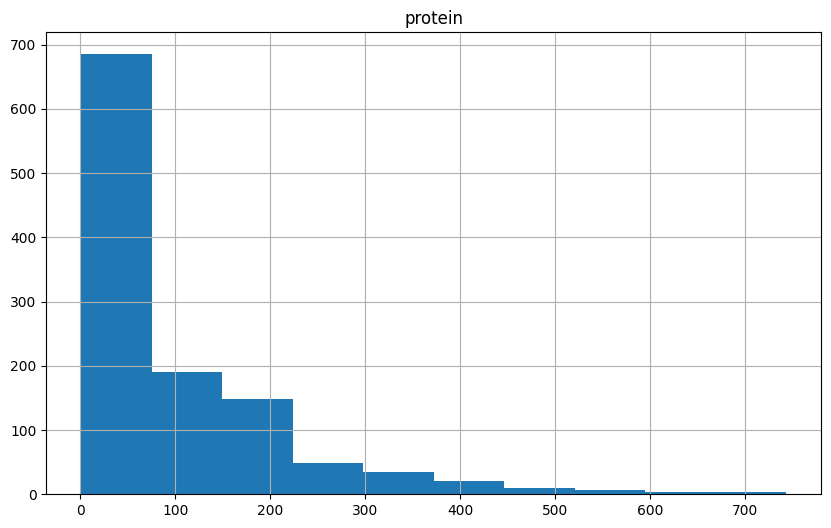

In [ ]:
# 9. STATISTIK DATA
# ==============================
print("\nStatistik data:")
print(df.describe())

fitur_plot = [col for col in ['kalium', 'natrium', 'protein'] if col in df.columns]

df[fitur_plot].hist(figsize=(10,6))
plt.show()

In [ ]:
# 11. BUAT DESKRIPSI UNTUK RAG
# ==============================
def generate_description(row):
    return (
        f"{row.get('makanan', 'Makanan ini')} mengandung "
        f"{row.get('kalori', 0)} kkal energi, "
        f"{row.get('protein', 0)} gram protein, "
        f"{row.get('natrium', 0)} mg natrium, "
        f"{row.get('kalium', 0)} mg kalium, "
        f"dan {row.get('fosfor', 0)} mg fosfor."
    )

df['deskripsi'] = df.apply(generate_description, axis=1)

In [ ]:
# 12. SIMPAN DATA
# ==============================
df.to_csv('/content/drive/MyDrive/capstone/nutrisi_clean.csv', index=False)

print("\n Dataset berhasil dibersihkan dan siap untuk RAG!")
df.head()


 Dataset berhasil dibersihkan dan siap untuk RAG!


,no.,kode baru,makanan,air,energi,protein,lemak,karbohidrat,serat,abu,...,karoten total,thiamin (vit. b1),riboflavin (vit. b2),niasin,vitamin c,bdd,mentah / olahan,kelompok makanan,sumber tkpi 2019,deskripsi
1,1,AP001,Nasi,567,180,30.0,3.0,398.0,2,2,...,NaN,5,10,26,NaN,100,Olahan,Serealia,KZGPI-1990,"Nasi mengandung 0 kkal energi, 30.0 gram prote..."
2,2,AP002,Nasi tim,710,120,24.0,4.0,260.0,5,2,...,NaN,10,NaN,14,NaN,100,Olahan,Serealia,OKN-1992,"Nasi tim mengandung 0 kkal energi, 24.0 gram p..."
3,3,AP003,Tapai beras,755,99,17.0,3.0,224.0,NaN,1,...,NaN,NaN,NaN,NaN,NaN,100,Olahan,Serealia,KZGMI-2001,"Tapai beras mengandung 0 kkal energi, 17.0 gra..."
4,4,AP004,"Tepung beras, mentah",120,353,70.0,5.0,800.0,24,5,...,NaN,12,10,12,NaN,100,Olahan,Serealia,DABM-1964,"Tepung beras, mentah mengandung 0 kkal energi,..."
5,5,AP005,Nasi beras merah,640,149,28.0,4.0,325.0,3,3,...,NaN,6,NaN,16,NaN,100,Olahan,Serealia,KZGPI-1990,"Nasi beras merah mengandung 0 kkal energi, 28...."
